<a href="https://colab.research.google.com/github/syntaxJD/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


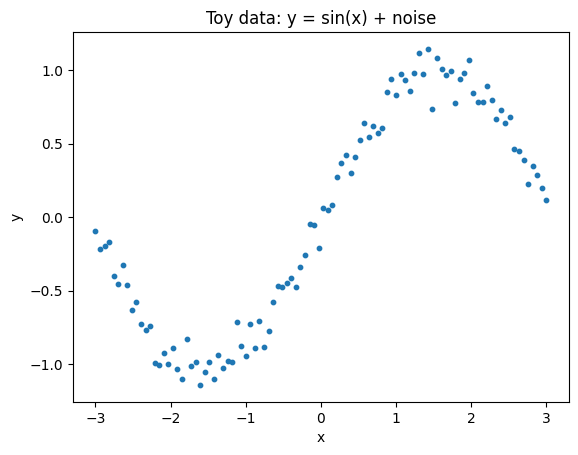

In [6]:
# --- Generate the toy data ---
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure()
plt.scatter(x, y, s=10)
plt.title("Toy data: y = sin(x) + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

In [8]:
lr = 0.05
steps = 200
losses = []

for step in range(steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

print(f"Final w={w:.3f}, b={b:.3f}, final loss={losses[-1]:.4f}")

Final w=0.339, b=-0.010, final loss=0.1955


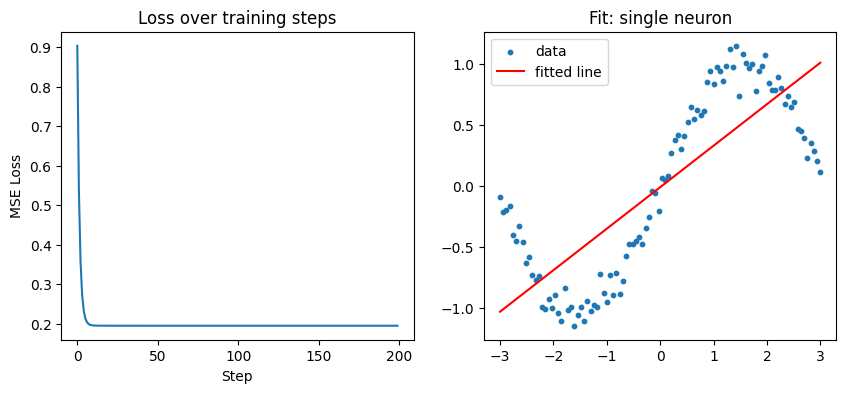

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(losses)
axes[0].set_title("Loss over training steps")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")

axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x, w * x + b, color="red", label="fitted line")
axes[1].set_title("Fit: single neuron")
axes[1].legend()

plt.show()

### Student Reasoning — The single neuron

**1. Derivation of dLoss/dw**

The model and loss are:

$$
\hat{y}_i = w x_i + b
$$

$$
L = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (w x_i + b - y_i)^2
$$

To find $\frac{\partial L}{\partial w}$, apply the chain rule. Let $u_i = w x_i + b - y_i$, so $L = \frac{1}{n}\sum u_i^2$.

$$
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} \frac{\partial}{\partial w}\left(u_i^2\right)
= \frac{1}{n} \sum_{i=1}^{n} 2 u_i \cdot \frac{\partial u_i}{\partial w}
$$

Since $u_i = w x_i + b - y_i$, we have $\frac{\partial u_i}{\partial w} = x_i$. Substituting:

$$
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2(w x_i + b - y_i)\, x_i
$$

$$
\boxed{\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)\, x_i}
$$

Similarly for $b$, since $\frac{\partial u_i}{\partial b} = 1$:

$$
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)
$$

**This matches the code exactly:**

```python
dw = np.mean(2 * (y_hat - y) * x)   # = (2/n) * sum((y_hat - y) * x)
db = np.mean(2 * (y_hat - y))       # = (2/n) * sum(y_hat - y)
```

`np.mean` computes $\frac{1}{n}\sum(\cdot)$, and multiplying by the `2 * (y_hat - y) * x` term inside gives exactly $\frac{2}{n}\sum(\hat{y}_i-y_i)x_i$ — identical to the derived formula.

---

**2. Underfitting, not overfitting**

The loss plateaus but the fit is still poor because a single neuron computes $\hat{y} = wx + b$, which is the equation of a **straight line**. No matter how long we train, or how small the loss gets relative to what a line can achieve, the *hypothesis space* of the model is restricted to lines. The function $y = \sin(x)$ is inherently curved, so there is no choice of $w$ and $b$ that can trace it — the best the model can do is find the single straight line that minimizes average squared error across the curve (roughly a line through the "middle" of the oscillation).

This is **underfitting**: the model's capacity, not the optimization process, is the bottleneck. Overfitting would instead look like the training loss continuing to drop while validation loss rises — i.e., the model has *enough* capacity to fit the data (even its noise) but generalizes poorly. Here we have the opposite problem: the model doesn't have enough capacity to represent the true function at all, regardless of how well-tuned the learning rate or how many steps we run.

In [10]:
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)

In [11]:
lr = 0.01
steps = 3000
losses_hidden = []

for step in range(steps):
    # Forward
    z1 = x_col @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_col) ** 2)
    losses_hidden.append(loss)

    # Backward
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

print(f"Final loss (with tanh): {losses_hidden[-1]:.5f}")

Final loss (with tanh): 0.02274


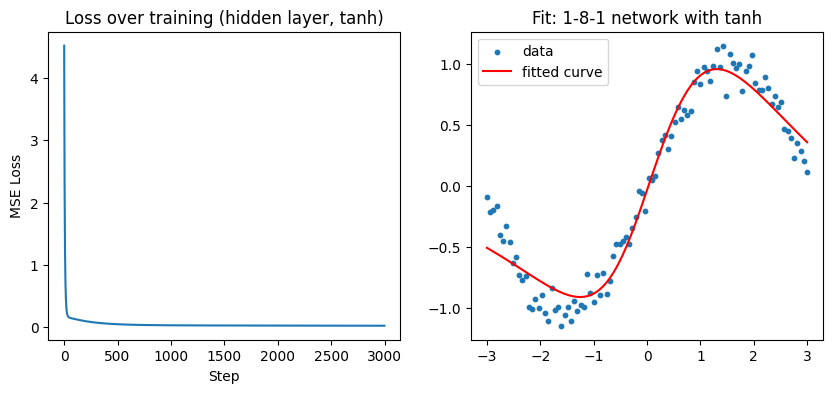

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(losses_hidden)
axes[0].set_title("Loss over training (hidden layer, tanh)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")

order = np.argsort(x)
axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x[order], y_hat[order], color="red", label="fitted curve")
axes[1].set_title("Fit: 1-8-1 network with tanh")
axes[1].legend()

plt.show()

In [13]:
np.random.seed(RANDOM_STATE)
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.random.randn(8) * 0.5
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.random.randn(1) * 0.5

losses_linear = []
for step in range(steps):
    z1 = x_col @ W1_lin + b1_lin
    h = z1                       # <-- tanh removed
    y_hat_lin = h @ W2_lin + b2_lin
    loss = np.mean((y_hat_lin - y_col) ** 2)
    losses_linear.append(loss)

    d_yhat = 2 * (y_hat_lin - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2_lin.T
    dz1 = dh                     # derivative of identity function is 1, so gradient passes straight through
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    W1_lin -= lr * dW1
    b1_lin -= lr * db1
    W2_lin -= lr * dW2
    b2_lin -= lr * db2

print(f"Final loss (no activation): {losses_linear[-1]:.5f}")

Final loss (no activation): 0.19545


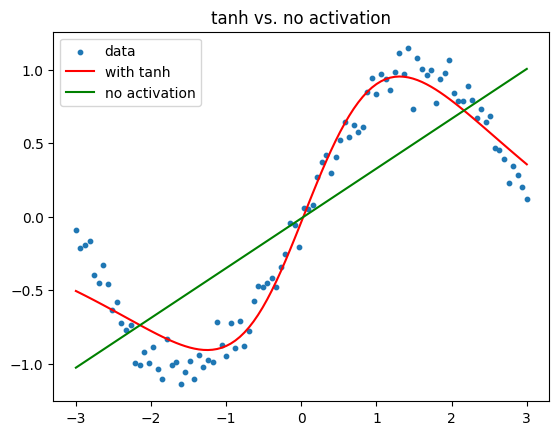

In [14]:
plt.figure()
plt.scatter(x, y, s=10, label="data")
plt.plot(x[order], y_hat[order], color="red", label="with tanh")
plt.plot(x[order], y_hat_lin[order], color="green", label="no activation")
plt.legend()
plt.title("tanh vs. no activation")
plt.show()

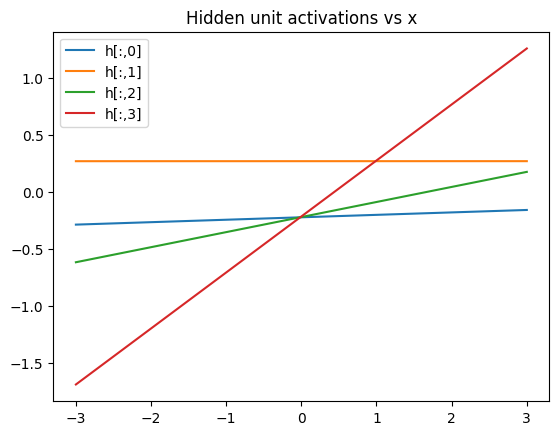

In [15]:
plt.figure()
for i in range(4):
    plt.plot(x[order], h[order, i], label=f"h[:,{i}]")
plt.legend()
plt.title("Hidden unit activations vs x")
plt.show()

Student Reasoning — Depth and activations 1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer. 2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.) 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?

Answer: [Without tanh: y_hat = (x@W1 + b1)@W2 + b2 = x@(W1@W2) + (b1@W2 + b2). Since W1@W2 is just some new matrix and b1@W2+b2 is just some new vector, this whole expression has the exact same form as a single linear layer x@W' + b'. Stacking linear layers without nonlinearity between them collapses to one linear layer — depth adds no representational power at all.
Each of the 8 hidden neurons learns its own bent version of tanh (shifted/scaled differently based on its weights), and the output layer is just a weighted sum of these 8 curves — combining several "bends" lets the network approximate the smooth curve of a sine wave that one straight line never could.
Backpropagation, one sentence: it's the repeated application of the chain rule to propagate the loss's gradient backward through each layer, so every weight learns exactly how much it contributed to the final error.]

In [ ]:
def train_toy(lr, steps=3000, seed=RANDOM_STATE):
    np.random.seed(seed)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []
    for step in range(steps):
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

In [ ]:
lrs = [0.001, 0.05, 1.0]
results = {lr: train_toy(lr) for lr in lrs}

plt.figure(figsize=(7, 5))
for lr, losses in results.items():
    plt.plot(losses, label=f"lr={lr}")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.legend()
plt.title("Effect of learning rate")
plt.show()

Student Reasoning — Learning rate Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

Answer: [Too-small lr wastes most of the 3000 steps barely moving. The good lr converges steadily. Too-large lr overshoots the minimum on every step — since the gradient step is w -= lr*dw, an oversized step doesn't land near the bottom of the loss curve, it leaps to the opposite side, where the slope is now even steeper, producing a bigger step next time — a runaway feedback loop rather than merely "faster" learning.]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

OBESITY_URL = "<paste the same URL you used in Lab 2>"
df = pd.read_csv(OBESITY_URL)

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

multi_cat_cols = ["CAEC", "CALC", "MTRANS"]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

target_encoder = LabelEncoder()
df["NObeyesdad"] = target_encoder.fit_transform(df["NObeyesdad"])

X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def to_tensor_dataset(X_arr, y_arr):
    X_t = torch.tensor(X_arr, dtype=torch.float32)
    y_t = torch.tensor(y_arr.values, dtype=torch.long)
    return TensorDataset(X_t, y_t)

train_ds = to_tensor_dataset(X_train_scaled, y_train)
val_ds = to_tensor_dataset(X_val_scaled, y_val)
test_ds = to_tensor_dataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

input_dim = X_train_scaled.shape[1]
print("Input dim:", input_dim)

Student Reasoning — Preprocessing for neural networks 1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch? 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1. 3. What does shuffle=True on the training DataLoader do, and why does it help?

Answer: [CrossEntropyLoss internally applies log-softmax and picks out the log-probability of the correct class by index — this is mathematically identical to one-hot cross-entropy but avoids constructing and storing a big one-hot matrix, so PyTorch just asks for the class index directly.
Random forests split on thresholds of raw feature values (e.g. "is age > 30?"), so the scale of a feature doesn't change which split is "best." Neural nets update via gradients that are literally proportional to the input value itself (recall dw = mean(2*(y_hat-y)*x) from Part 1.1) — a feature on a scale of thousands would dominate the gradient and drown out a feature on a 0-1 scale, distorting and slowing training.
shuffle=True randomizes the order data is drawn into batches each epoch, so each mini-batch gradient is a more representative, less biased sample of the full training set (rather than, say, all-one-class batches if data happened to be sorted).]